In [26]:
import pandas as pd

In [27]:
df = pd.read_csv(r'C:\Users\HP\OneDrive\Desktop\KPMG sem3\Time Series\Time-Series-Dataset.csv')

In [28]:
df.head(10)

,Date,Company,Open,High,Low,Close,Volume
0,2016-01-01,HCLTech,1545.39,1552.22,1536.89,1550.00,1956151
1,2016-01-01,Infosys,1842.72,1860.80,1828.59,1850.00,3706077
2,2016-01-01,TCS,3606.28,3622.06,3567.02,3600.00,1622560
3,2016-01-01,Wipro,701.00,704.40,697.61,700.00,3072354
4,2016-01-04,HCLTech,1566.69,1576.56,1550.24,1567.92,2207225
5,2016-01-04,Infosys,1838.12,1850.08,1817.29,1835.26,2548473
6,2016-01-04,TCS,3571.63,3592.16,3561.08,3568.83,1721751
7,2016-01-04,Wipro,683.51,687.93,675.58,683.73,3580823
8,2016-01-05,HCLTech,1574.81,1584.95,1566.81,1571.18,3844036
9,2016-01-05,Infosys,1815.43,1825.25,1778.32,1796.08,3482771


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     10000 non-null  object 
 1   Company  10000 non-null  object 
 2   Open     10000 non-null  float64
 3   High     10000 non-null  float64
 4   Low      10000 non-null  float64
 5   Close    10000 non-null  float64
 6   Volume   10000 non-null  int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 547.0+ KB


In [30]:
df['Date']= pd.to_datetime(df['Date'])

In [31]:
df.dtypes

Date       datetime64[ns]
Company            object
Open              float64
High              float64
Low               float64
Close             float64
Volume              int64
dtype: object

In [32]:
df = df.sort_values('Date').copy()
df.set_index('Date', inplace=True)
df.head()

,Company,Open,High,Low,Close,Volume
Date,,,,,,
2016-01-01,HCLTech,1545.39,1552.22,1536.89,1550.00,1956151
2016-01-01,Infosys,1842.72,1860.80,1828.59,1850.00,3706077
2016-01-01,TCS,3606.28,3622.06,3567.02,3600.00,1622560
2016-01-01,Wipro,701.00,704.40,697.61,700.00,3072354
2016-01-04,HCLTech,1566.69,1576.56,1550.24,1567.92,2207225


In [33]:
df.isnull().sum()

Company    0
Open       0
High       0
Low        0
Close      0
Volume     0
dtype: int64

In [34]:
df.duplicated().sum()

np.int64(0)

# which company has highest average closing price

Company    0
Open       0
High       0
Low        0
Close      0
Volume     0
dtype: int64

Company count:
Company
HCLTech    2500
Infosys    2500
TCS        2500
Wipro      2500
Name: count, dtype: int64

Close price summary by company:
                 mean           std      min       max
Company                                               
HCLTech  10695.276284  10838.399410  1501.06  41805.20
Infosys   3686.948628   1849.970799  1565.36   8731.91
TCS       5621.397644   1055.223060  3506.06   7996.09
Wipro      491.327928    156.786237   228.48    826.89


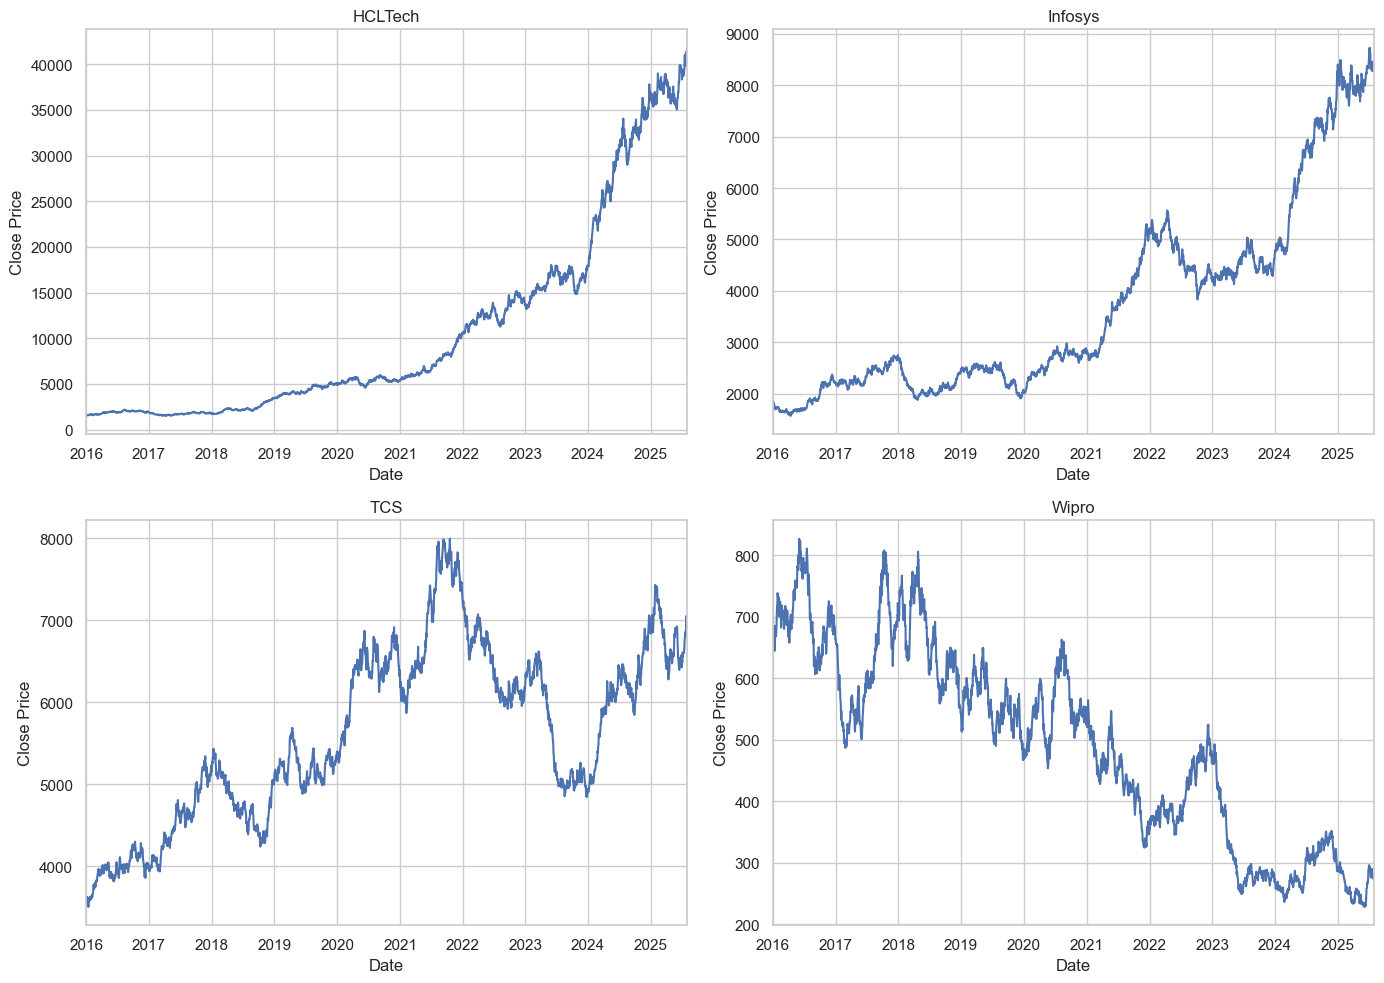

In [35]:
import matplotlib.pyplot as plt

# Check for missing values
print(df.isna().sum())
print('\nCompany count:')
print(df['Company'].value_counts())

# Summary statistics by company
summary = df.groupby('Company')['Close'].agg(['mean', 'std', 'min', 'max'])
print('\nClose price summary by company:')
print(summary)

# Visualize closing prices for each company over time
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (company, group) in zip(axes, df.groupby('Company')):
    group['Close'].plot(ax=ax, title=company)
    ax.set_xlabel('Date')
    ax.set_ylabel('Close Price')

for ax in axes[len(df['Company'].unique()):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

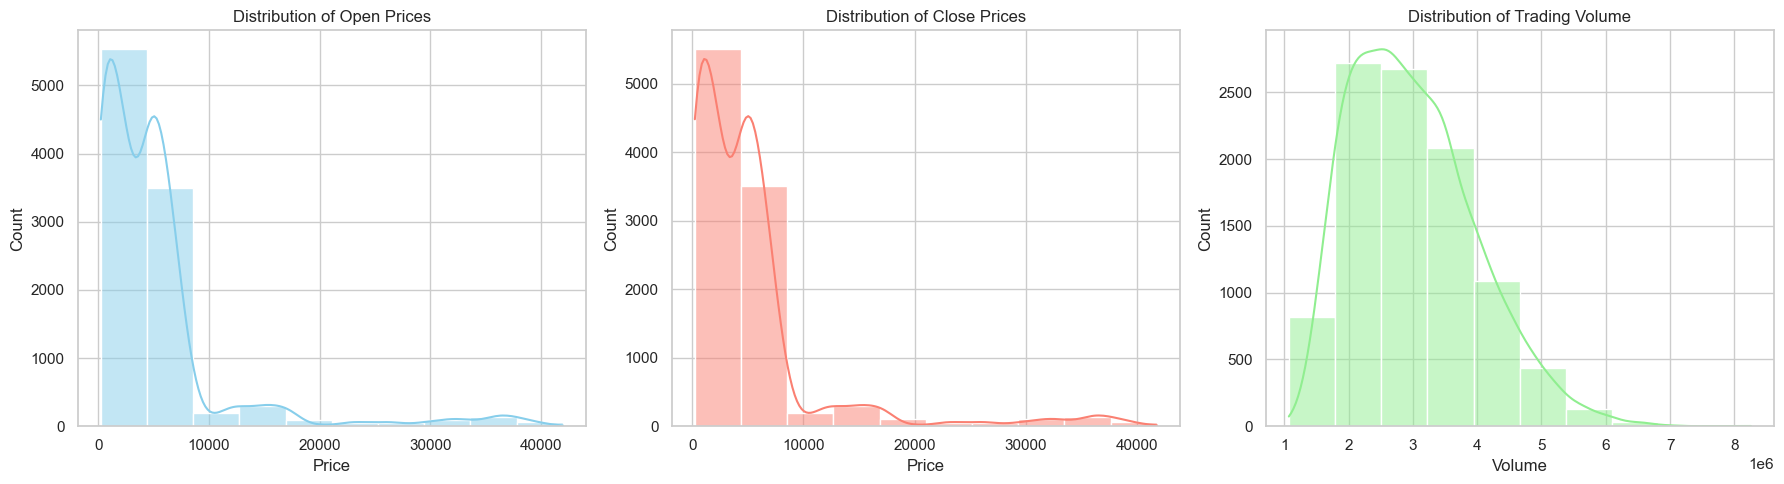

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plotting area (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histogram for Open Price
sns.histplot(data=df, x='Open', bins=10, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Open Prices')
axes[0].set_xlabel('Price')

# 2. Histogram for Close Price
sns.histplot(data=df, x='Close', bins=10, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Close Prices')
axes[1].set_xlabel('Price')

# 3. Histogram for Volume
sns.histplot(data=df, x='Volume', bins=10, kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribution of Trading Volume')
axes[2].set_xlabel('Volume')

plt.tight_layout()
plt.show()


# which  company is hghest volatile
* Hcl tech (Light blue ): shows highest volatile and overall highest price rangethe median sits around 8000, but it has massive upper wisker sketch past 30,000.

* infosys(pink): Display very stable low price range with few outlier

* TCS(Blue):  shows tightly bound distribustion highly consisitent around 6000.

Wipro(Purple): stock price is sighly lower

C:\Users\HP\AppData\Local\Temp\ipykernel_1964\3907546605.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Company', y='Close', ax=axes[0], palette='Set2')
C:\Users\HP\AppData\Local\Temp\ipykernel_1964\3907546605.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Company', y='Volume', ax=axes[1], palette='Set2')


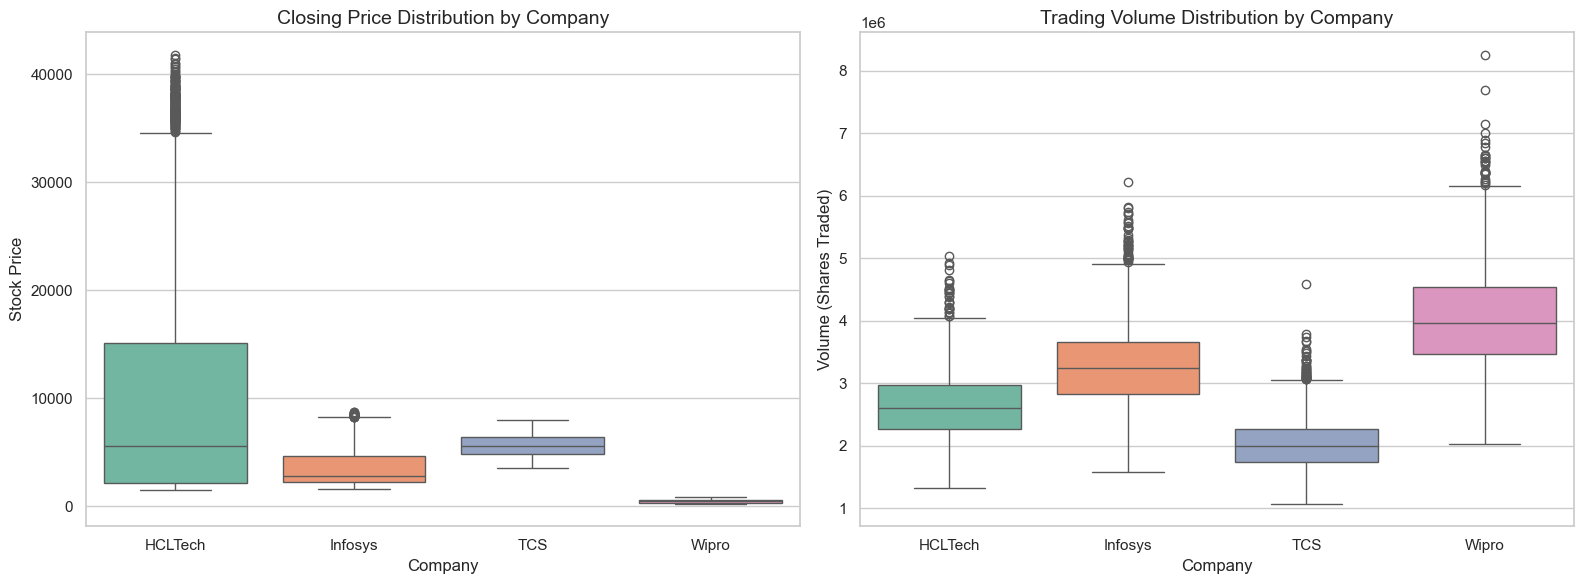

In [37]:
# boxplot by company

import matplotlib.pyplot as plt
import seaborn as sns

# Set up a plotting area with 2 subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Boxplot for Closing Prices by Company
sns.boxplot(data=df, x='Company', y='Close', ax=axes[0], palette='Set2')
axes[0].set_title('Closing Price Distribution by Company', fontsize=14)
axes[0].set_ylabel('Stock Price')
axes[0].set_xlabel('Company')

# 2. Boxplot for Volume by Company
sns.boxplot(data=df, x='Company', y='Volume', ax=axes[1], palette='Set2')
axes[1].set_title('Trading Volume Distribution by Company', fontsize=14)
axes[1].set_ylabel('Volume (Shares Traded)')
axes[1].set_xlabel('Company')

# Optimize layout and display
plt.tight_layout()
plt.show()


In [38]:
df.describe()


,Open,High,Low,Close,Volume
count,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04
mean,5123.855802,5166.290303,5081.872127,5123.737621,3.007248e+06
std,6648.821457,6706.447091,6593.561095,6648.562456,9.752652e+05
min,227.840000,228.800000,225.260000,228.480000,1.071706e+06
25%,1324.365000,1340.662500,1311.302500,1332.517500,2.242330e+06
50%,3982.120000,4011.200000,3954.045000,3981.080000,2.885760e+06
75%,6076.437500,6117.042500,6024.525000,6070.382500,3.612393e+06
max,41975.620000,42065.790000,41700.540000,41805.200000,8.256660e+06


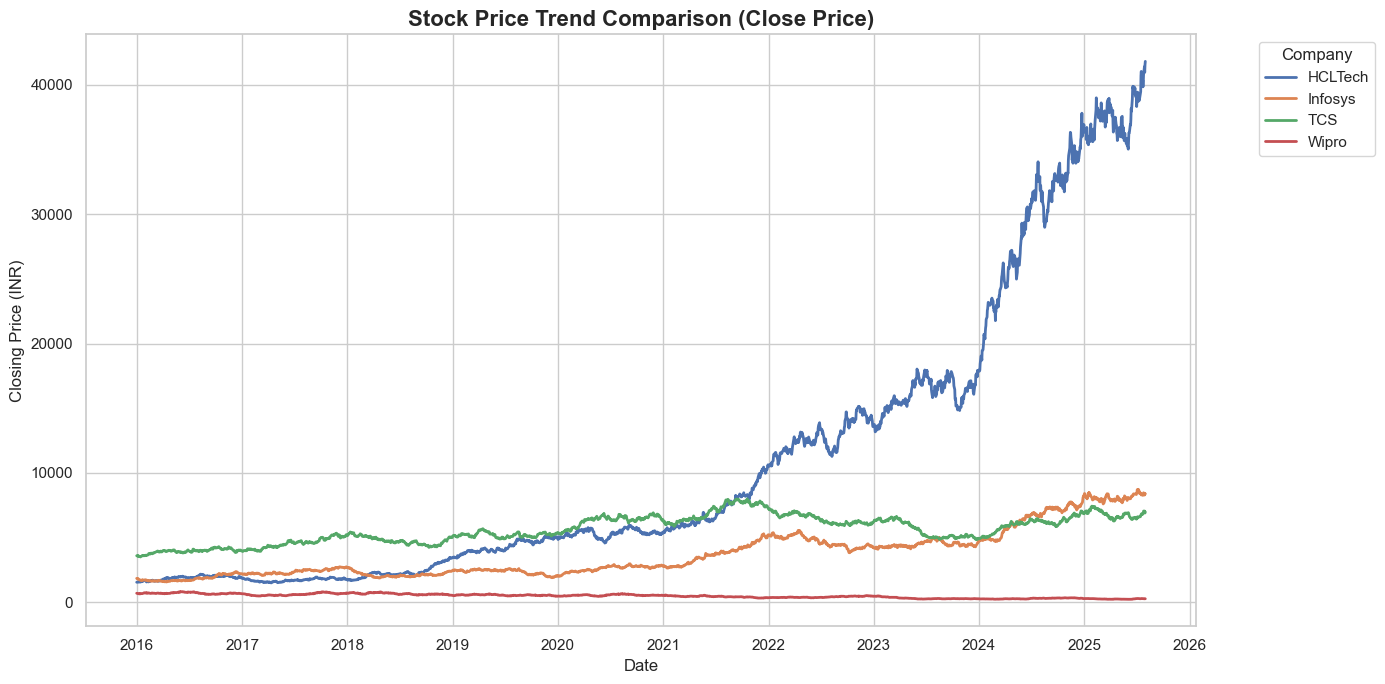

In [39]:
# compare each company’s price trend

# Ensure Date is in datetime format and data is sorted chronologically


# Set up the plot style
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# Plot the lines for each company
sns.lineplot(data=df, x='Date', y='Close', hue='Company', linewidth=2)

# Customize titles and labels
plt.title('Stock Price Trend Comparison (Close Price)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Closing Price (INR)', fontsize=12)
plt.legend(title='Company', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


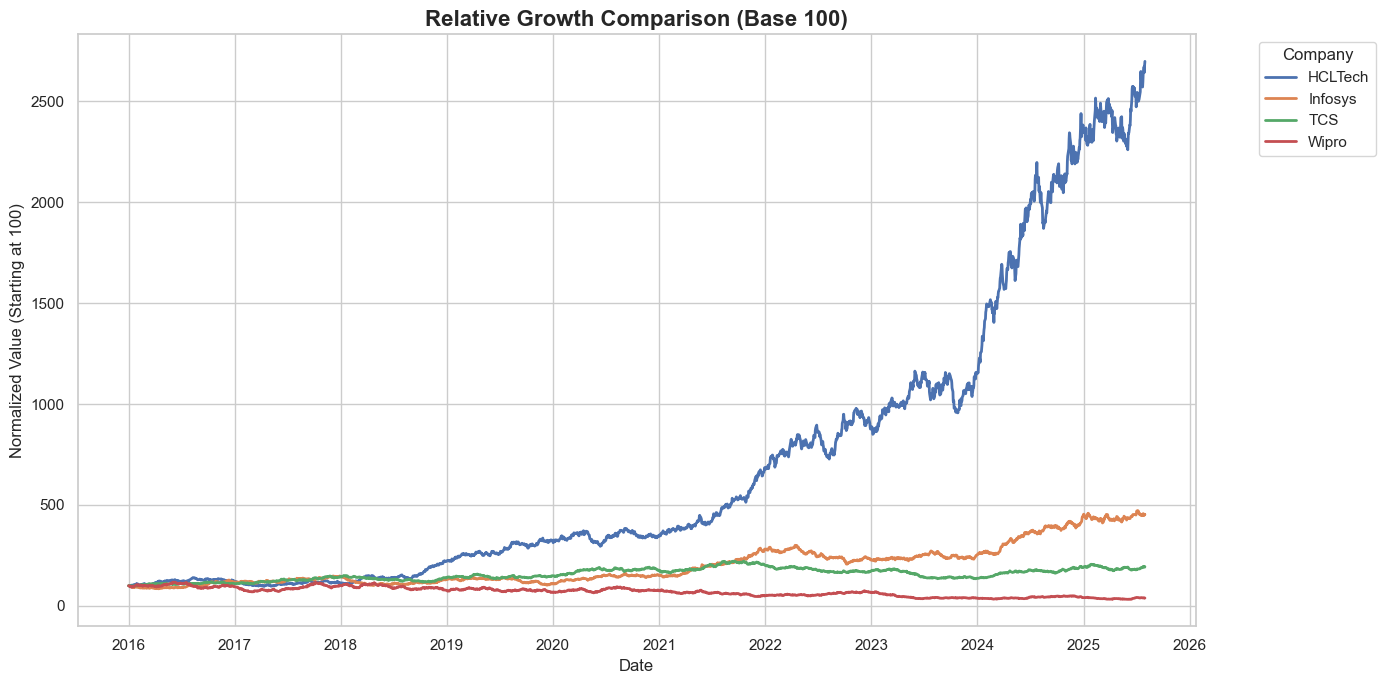

In [40]:
# Function to normalize prices to start at 100
df['Normalized_Close'] = df.groupby('Company')['Close'].transform(lambda x: (x / x.iloc[0]) * 100)

# Plotting the normalized trend
plt.figure(figsize=(14, 7))
sns.lineplot(data=df, x='Date', y='Normalized_Close', hue='Company', linewidth=2)

plt.title('Relative Growth Comparison (Base 100)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Normalized Value (Starting at 100)', fontsize=12)
plt.legend(title='Company', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


In [51]:
# Calculate daily returns for each company
df['Daily_Return'] = df.groupby('Company')['Close'].pct_change()

# Display the daily returns
df[['Company',  'Daily_Return']].head(20)



,Company,Daily_Return
Date,,
2016-01-01,HCLTech,NaN
2016-01-01,Infosys,NaN
2016-01-01,TCS,NaN
2016-01-01,Wipro,NaN
2016-01-04,HCLTech,0.011561
2016-01-04,Infosys,-0.007968
2016-01-04,TCS,-0.008658
2016-01-04,Wipro,-0.023243
2016-01-05,Wipro,-0.005309


# volatility

In [50]:
# volatility; standard deviation of daily return 

volatility=(
    df.groupby("Company")['Daily_Return']
    .std()
    .sort_values(ascending=False)
)
volatility *100

Company
Wipro      1.823351
HCLTech    1.432379
Infosys    1.211731
TCS        0.907514
Name: Daily_Return, dtype: float64

### moving Average 

In [65]:
# Calculate the 20-day moving average separately for each company
df['MA_20'] = (
    df.groupby('Company')['Close']
      .transform(lambda prices: prices.rolling(window=20).mean())
)
df.head(25)
# df[['Company', 'Close', 'MA_20']].head(30)

,Company,Open,High,Low,Close,Volume,Normalized_Close,Daily_Return,MA_20
Date,,,,,,,,,
2016-01-01,HCLTech,1545.39,1552.22,1536.89,1550.00,1956151,100.000000,NaN,NaN
2016-01-01,Infosys,1842.72,1860.80,1828.59,1850.00,3706077,100.000000,NaN,NaN
2016-01-01,TCS,3606.28,3622.06,3567.02,3600.00,1622560,100.000000,NaN,NaN
2016-01-01,Wipro,701.00,704.40,697.61,700.00,3072354,100.000000,NaN,NaN
2016-01-04,HCLTech,1566.69,1576.56,1550.24,1567.92,2207225,101.156129,0.011561,NaN
2016-01-04,Infosys,1838.12,1850.08,1817.29,1835.26,2548473,99.203243,-0.007968,NaN
2016-01-04,TCS,3571.63,3592.16,3561.08,3568.83,1721751,99.134167,-0.008658,NaN
2016-01-04,Wipro,683.51,687.93,675.58,683.73,3580823,97.675714,-0.023243,NaN
2016-01-05,Wipro,677.96,686.43,674.62,680.10,4497867,97.157143,-0.005309,NaN


In [72]:
df.tail(20)

,Company,Open,High,Low,Close,Volume,Normalized_Close,Daily_Return,MA_20
Date,,,,,,,,,
2025-07-25,HCLTech,40612.67,40974.73,40467.42,40801.95,2962690,2632.383871,0.014174,39572.4200
2025-07-25,Infosys,8456.06,8543.77,8405.72,8462.71,3227705,457.443784,0.011476,8450.7040
2025-07-25,TCS,7076.17,7106.12,6972.01,7052.20,1799605,195.894444,0.021561,6678.9225
2025-07-25,Wipro,278.31,282.72,276.86,280.31,4582485,40.044286,-0.009120,285.9645
2025-07-28,HCLTech,41425.20,41651.86,41196.57,41394.35,2868706,2670.603226,0.014519,39692.2560
2025-07-28,Infosys,8325.02,8374.31,8192.55,8288.62,4095744,448.033514,-0.020571,8448.6145
2025-07-28,TCS,7046.97,7114.79,6997.86,7054.59,1834063,195.960833,0.000339,6710.2440
2025-07-28,Wipro,272.32,276.73,271.53,274.47,4282533,39.210000,-0.020834,285.2795
2025-07-29,Wipro,279.93,284.73,277.20,281.97,3734983,40.281429,0.027325,284.9935


In [73]:
# Calculate the 30-day moving average separately for each company
df['MA_30'] = (
    df.groupby('Company')['Close']
      .transform(lambda prices: prices.rolling(window=30).mean())
)

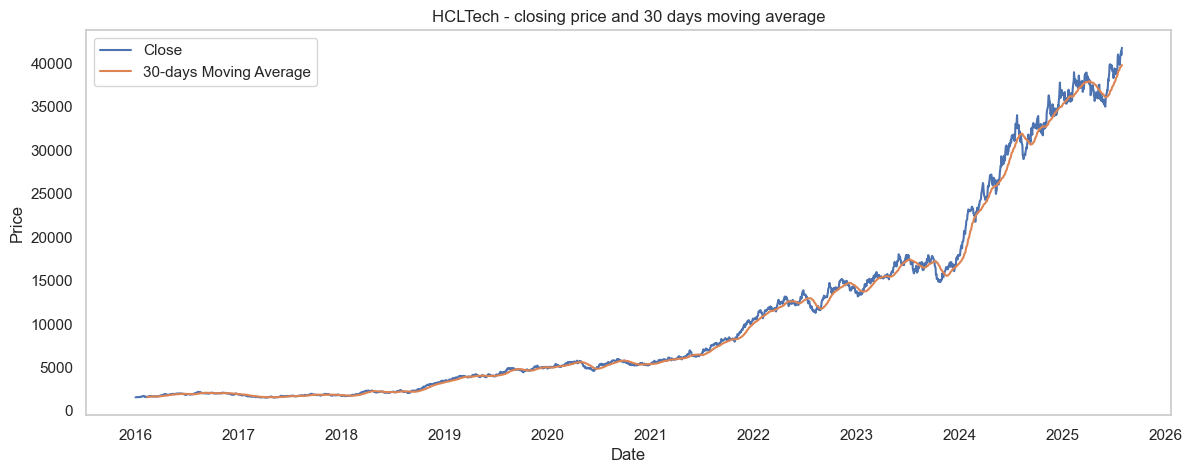

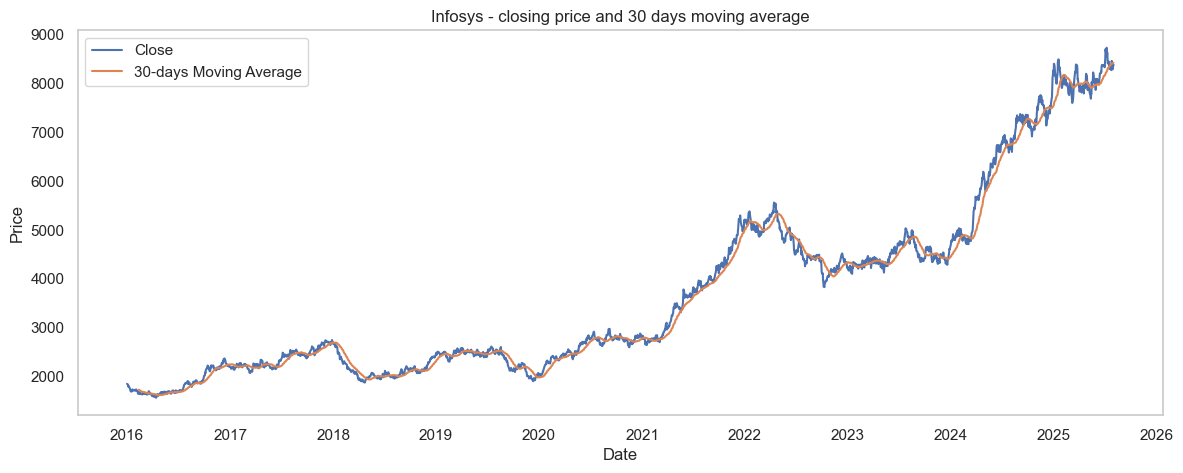

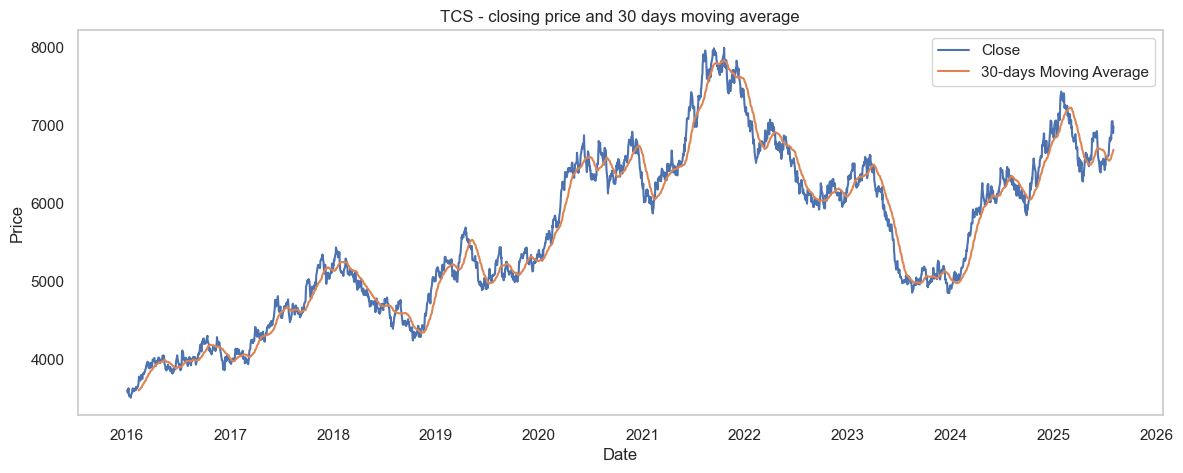

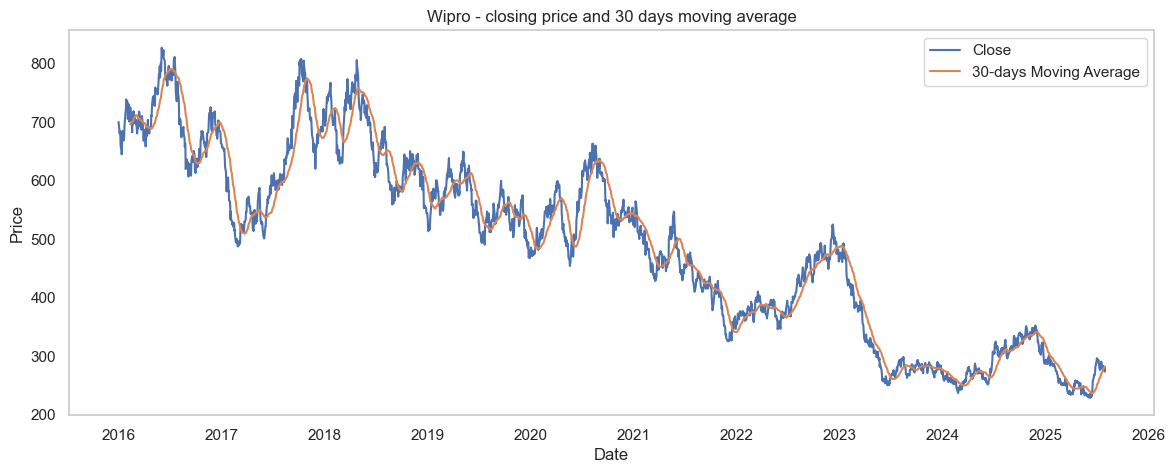

In [79]:
# compare company using moving Average 

for company in df['Company'].unique():
    company_data = df[df['Company'] == company]

    plt.figure(figsize=(14, 5))
    plt.plot(
        company_data.index,
        company_data["Close"],
        label="Close"
    )

    plt.plot(
        company_data.index,
        company_data["MA_30"],
        label="30-days Moving Average"
    )

    plt.title(f'{company} - closing price and 30 days moving average')
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.grid()

    plt.show()



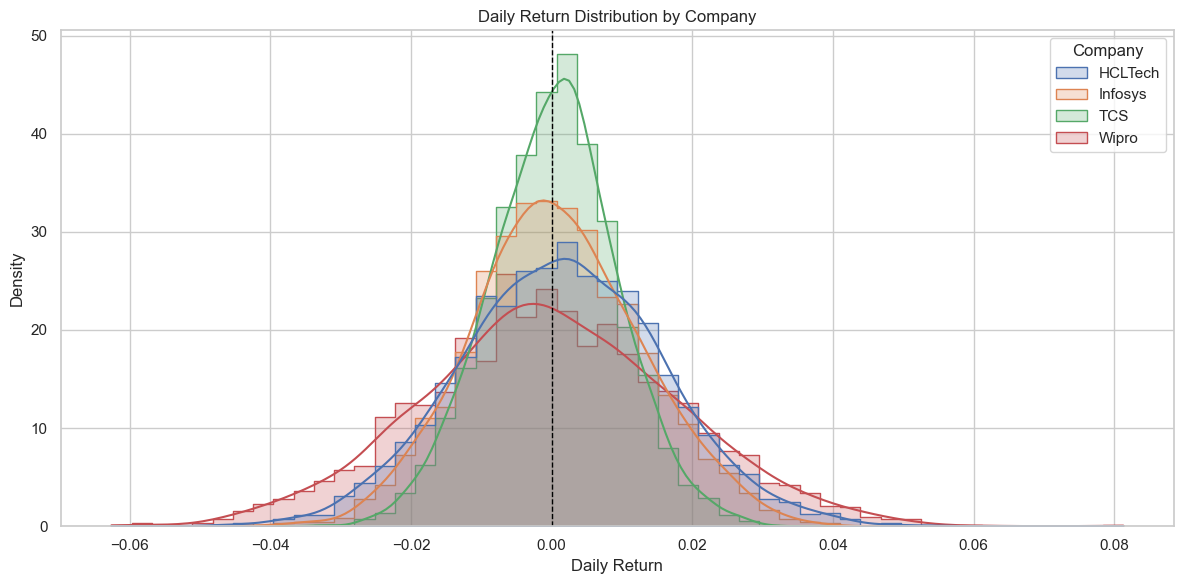

In [45]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df.dropna(subset=['Daily_Return']),
    x='Daily_Return',
    hue='Company',
    bins=50,
    kde=True,
    element='step',
    stat='density',
    common_norm=False
)

plt.title('Daily Return Distribution by Company')
plt.xlabel('Daily Return')
plt.ylabel('Density')
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

,Open,High,Low,Close
Open,1.000000,0.999986,0.999986,0.999982
High,0.999986,1.000000,0.999977,0.999987
Low,0.999986,0.999977,1.000000,0.999985
Close,0.999982,0.999987,0.999985,1.000000


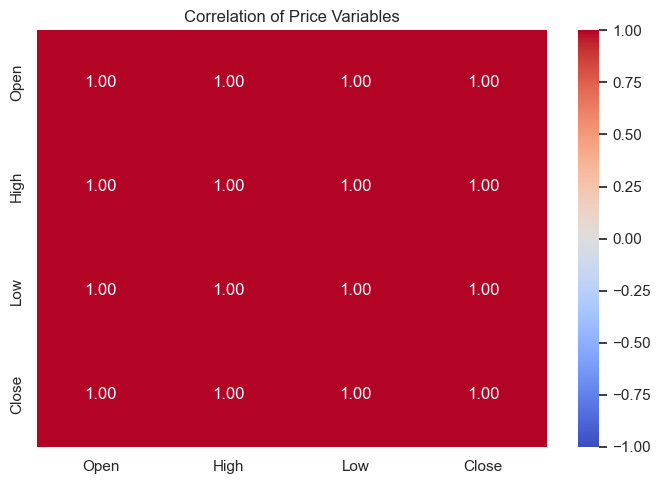

In [47]:
# Correlation among price variables
price_columns = ['Open', 'High', 'Low', 'Close']
price_correlation = df[price_columns].corr()

display(price_correlation)

plt.figure(figsize=(7, 5))
sns.heatmap(
    price_correlation,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    fmt='.2f'
)
plt.title('Correlation of Price Variables')
plt.tight_layout()
plt.show()

Overall correlation: 0.16669973215521602

Correlation by company:
Company
TCS       -0.001138
HCLTech   -0.006313
Infosys   -0.018033
Wipro     -0.034076
dtype: float64


C:\Users\HP\AppData\Local\Temp\ipykernel_1964\723602700.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group['Absolute_Return'].corr(


,mean,median
Return_Group,,
Low,2.864373e+06,2720088.0
Medium-Low,2.915965e+06,2753647.0
Medium-High,2.976964e+06,2841943.0
High,3.272358e+06,3187326.0


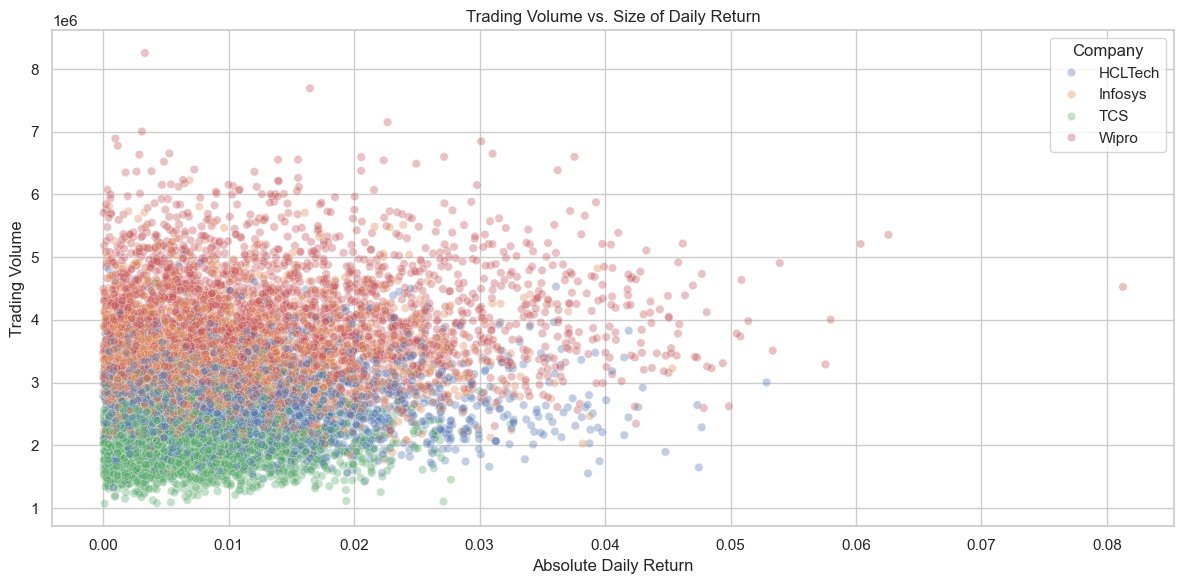

In [52]:
# Examine whether trading volume increases during large price movements
analysis_df = df[['Company', 'Volume', 'Daily_Return']].dropna().copy()
analysis_df['Absolute_Return'] = analysis_df['Daily_Return'].abs()

# Overall and company-wise Spearman correlations
print('Overall correlation:',
    analysis_df['Absolute_Return'].corr(analysis_df['Volume'], method='spearman'))

print('\nCorrelation by company:')
print(
    analysis_df.groupby('Company')
    .apply(lambda group: group['Absolute_Return'].corr(
      group['Volume'], method='spearman'
    ))
    .sort_values(ascending=False)
)

# Compare volume on normal-return and high-return days
analysis_df['Return_Group'] = pd.qcut(
    analysis_df['Absolute_Return'],
    q=4,
    labels=['Low', 'Medium-Low', 'Medium-High', 'High']
)

volume_comparison = analysis_df.groupby('Return_Group', observed=True)['Volume'].agg(
    ['mean', 'median']
)
display(volume_comparison)

# Visualize the relationship
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=analysis_df,
    x='Absolute_Return',
    y='Volume',
    hue='Company',
    alpha=0.35
)

plt.xlabel('Absolute Daily Return')
plt.ylabel('Trading Volume')
plt.title('Trading Volume vs. Size of Daily Return')
plt.tight_layout()
plt.show()